In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
# Set the random seed for reproducibility
np.random.seed(42)

In [5]:
# Create sample dataset with outliers
df = pd.DataFrame({
    'height': np.concatenate([
        np.random.normal(175, 7, 95),  # Normal heights in cm
        np.array([150, 155, 200, 205, 210])  # Outliers
    ]),
    'weight': np.concatenate([
        np.random.normal(70, 10, 95),  # Normal weights in kg
        np.array([40, 45, 120, 125, 130])  # Outliers
    ]),
    'salary': np.concatenate([
        np.random.lognormal(10.5, 0.4, 95),  # Normal salaries
        np.array([500000, 520000, 550000, 600000, 1000000])  # Outliers
    ])
})

In [6]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,178.476999,55.364851,30375.572226
1,174.032150,72.961203,51152.135370
2,179.533820,72.610553,39562.520524
3,185.661209,70.051135,22064.041668
4,173.360926,67.654129,38920.343822


In [7]:
# Quick data summary
df.describe()


,height,weight,salary
count,100.000000,100.000000,100.000000
mean,174.802581,71.397280,70575.816571
std,8.824677,13.932214,138019.017873
min,150.000000,40.000000,9931.760814
25%,170.712081,61.943395,27742.715939
50%,174.111306,70.841072,38441.915870
75%,178.918874,76.333889,51091.331090
max,210.000000,130.000000,1000000.000000


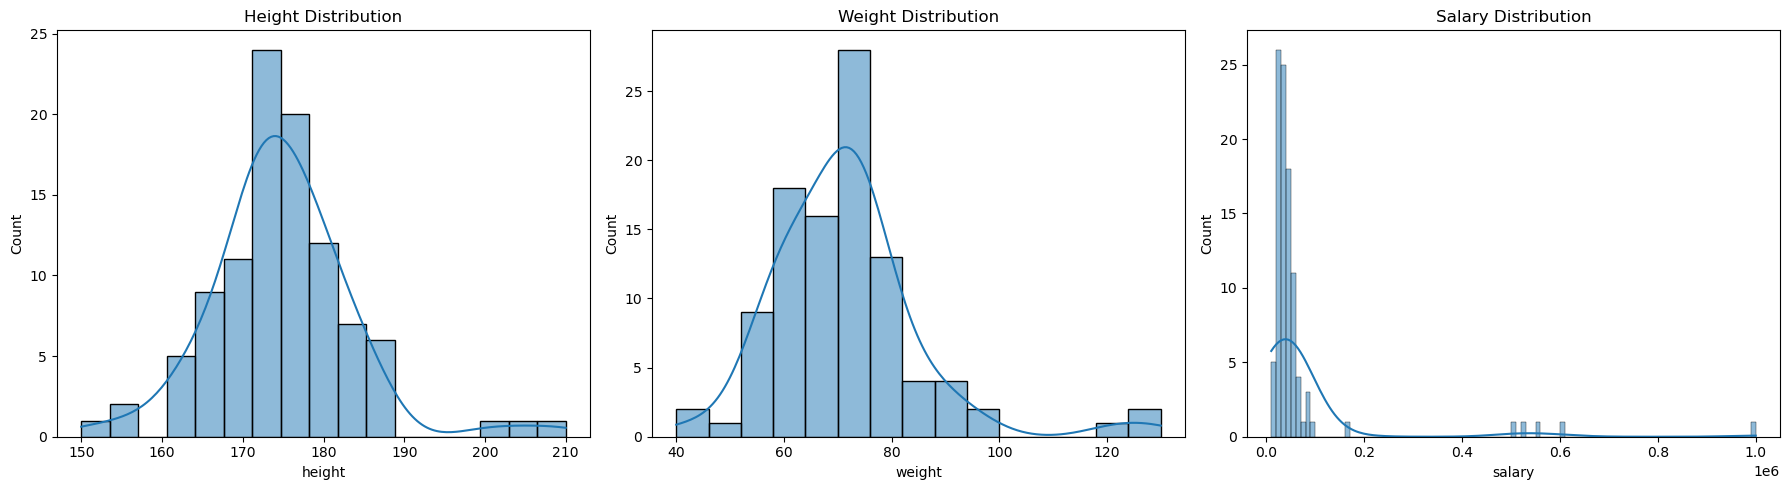

In [8]:
# Visualize distributions to identify potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['height'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')

plt.tight_layout()
plt.show()

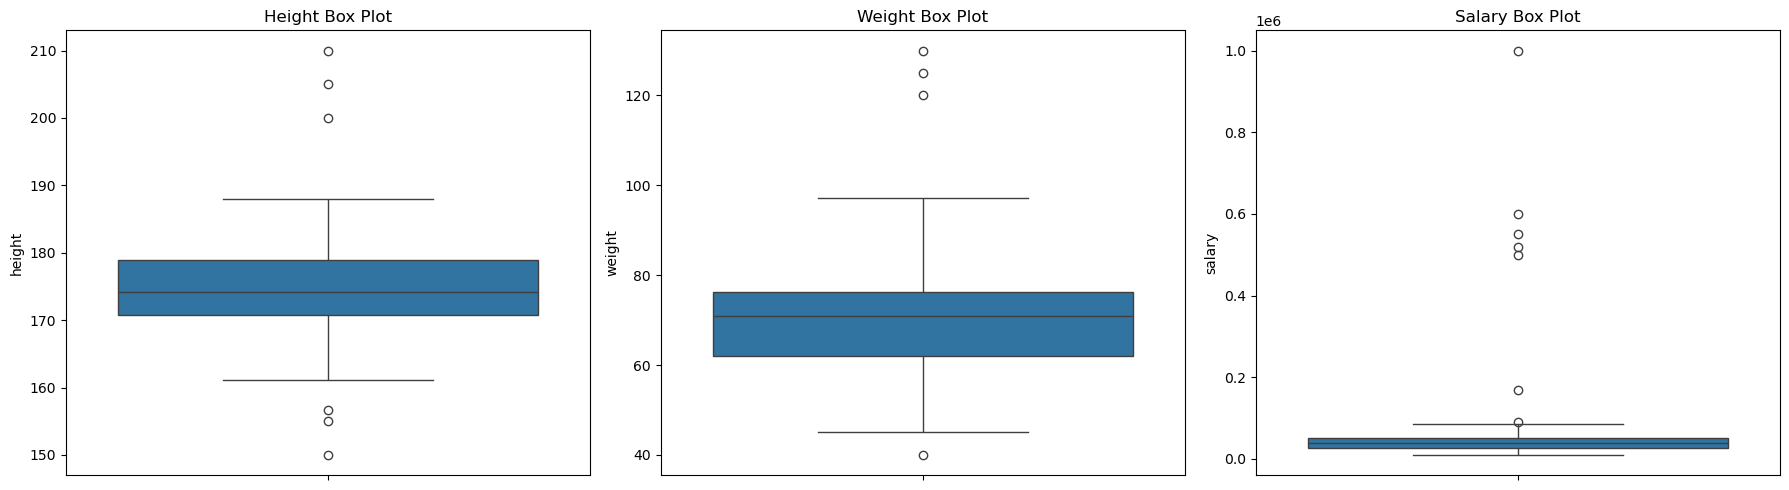

In [9]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

plt.tight_layout()
plt.show()

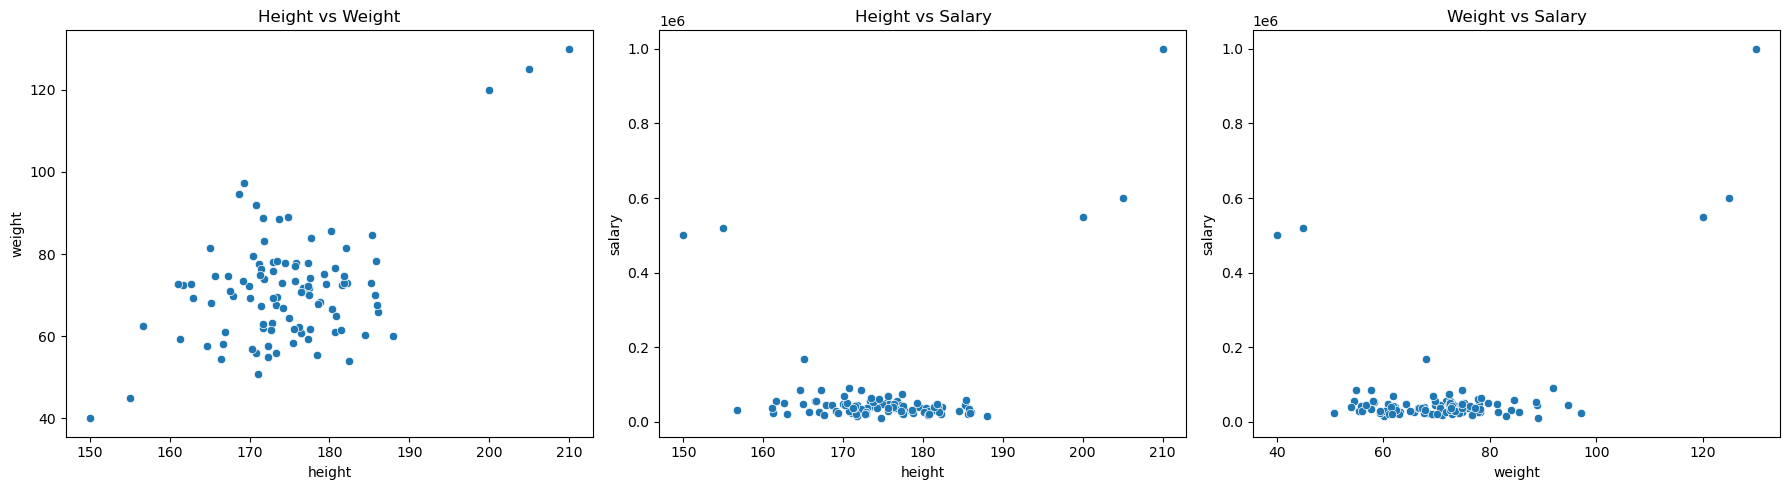

In [10]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [11]:
# Define function for Z-score outlier detection
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]


In [12]:
# Apply Z-score outlier detection
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score): {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score): {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score): {len(salary_outliers_z)} found at indices {salary_outliers_z}")


Height outliers (Z-score): 2 found at indices [98 99]
Weight outliers (Z-score): 3 found at indices [97 98 99]
Salary outliers (Z-score): 5 found at indices [95 96 97 98 99]


In [13]:
# Define function for IQR outlier detection
def detect_outliers_iqr(data, factor=1.5):
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]


In [14]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR): {len(height_outliers_iqr)} found at indices {height_outliers_iqr}")
print(f"Weight outliers (IQR): {len(weight_outliers_iqr)} found at indices {weight_outliers_iqr}")
print(f"Salary outliers (IQR): {len(salary_outliers_iqr)} found at indices {salary_outliers_iqr}")


Height outliers (IQR): 6 found at indices [74 95 96 97 98 99]
Weight outliers (IQR): 4 found at indices [95 97 98 99]
Salary outliers (IQR): 7 found at indices [19 30 95 96 97 98 99]


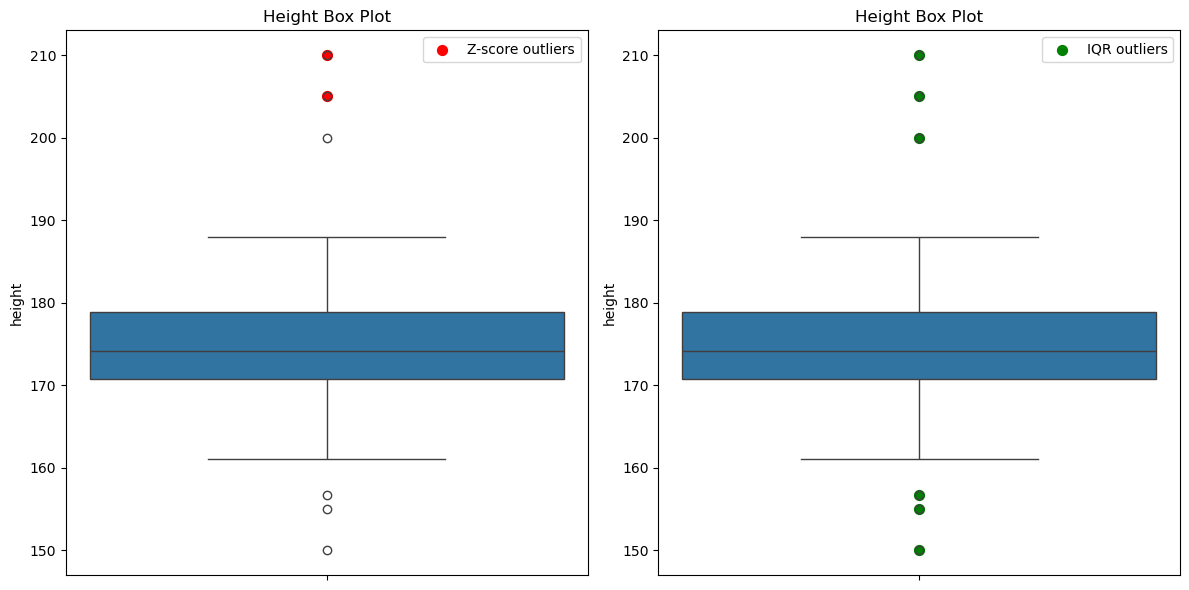

In [15]:
# Visualize the detected outliers for height using box plot with highlighted outliers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z],
            color='red', s=50, label='Z-score outliers')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_iqr), df['height'].iloc[height_outliers_iqr],
            color='green', s=50, label='IQR outliers')
plt.legend()

plt.tight_layout()
plt.show()


In [16]:
# Examining the impact of outliers on statistical measures
print("With outliers:")
print(f"Height mean: {df['height'].mean():.2f}, std: {df['height'].std():.2f}")
print(f"Weight mean: {df['weight'].mean():.2f}, std: {df['weight'].std():.2f}")
print(f"Salary mean: {df['salary'].mean():.2f}, std: {df['salary'].std():.2f}")


With outliers:
Height mean: 174.80, std: 8.82
Weight mean: 71.40, std: 13.93
Salary mean: 70575.82, std: 138019.02


In [17]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")



Without outliers:
Height mean: 174.65, std: 6.18
Weight mean: 70.19, std: 9.50
Salary mean: 39059.91, std: 15713.95


In [18]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)
def winsorize(data, limits=(0.05, 0.05)):
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])


In [19]:
# 3. Log transformation (especially useful for skewed data like salary)
df_log = df.copy()
df_log['salary'] = np.log(df['salary'])


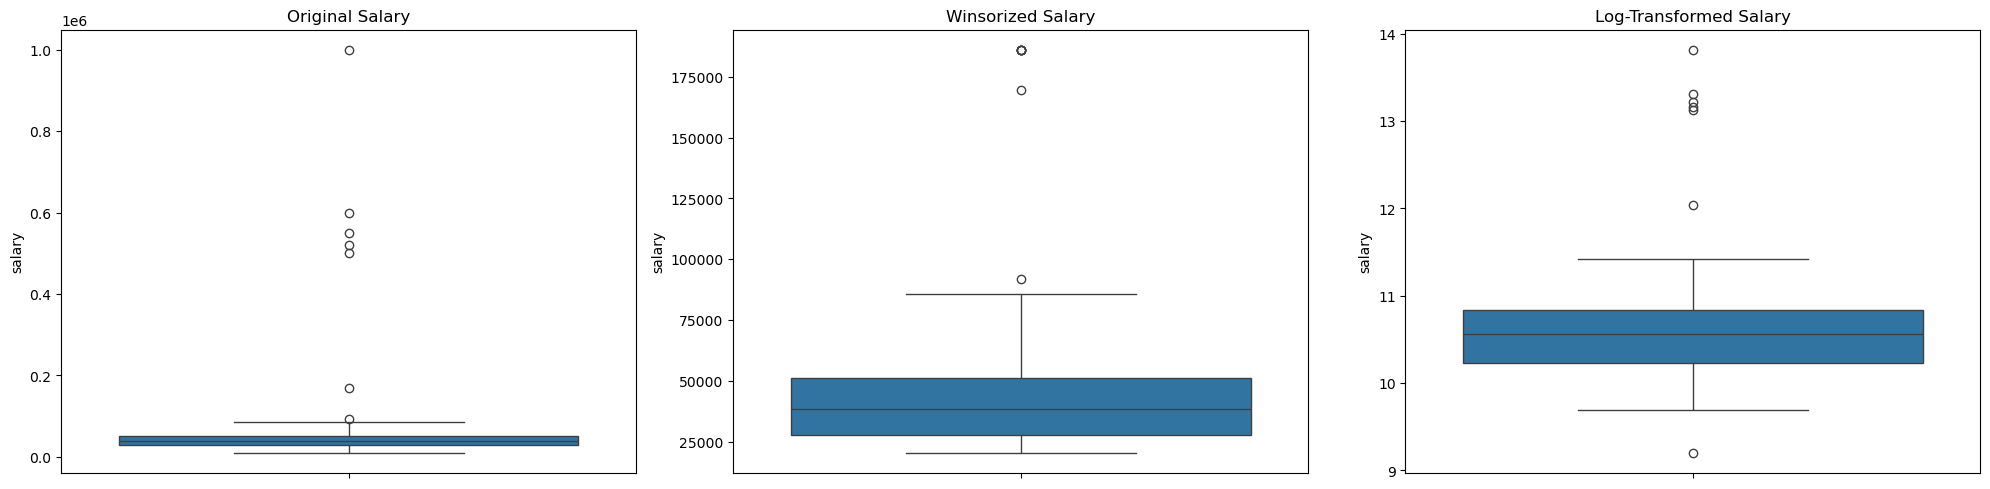

In [20]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [21]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()


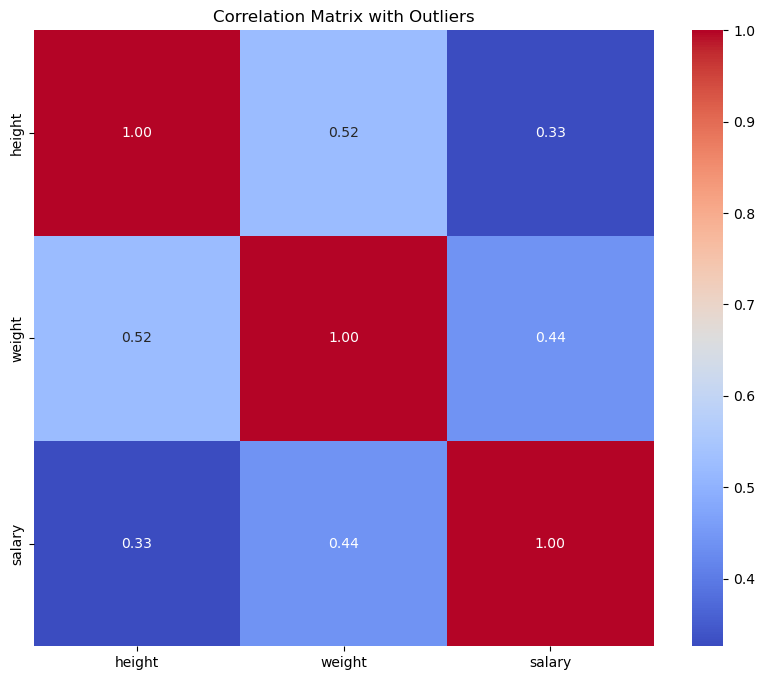

In [22]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()


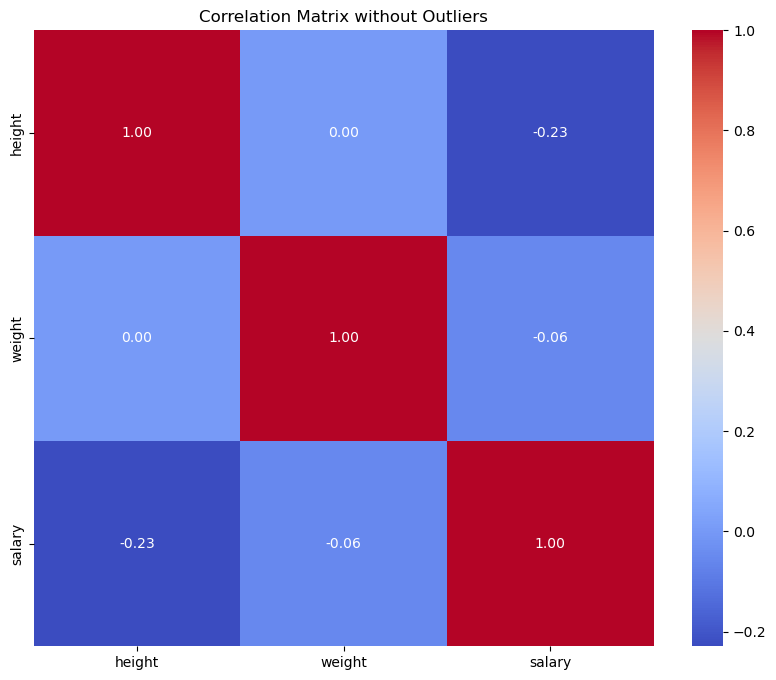

In [23]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()


In [24]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [25]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results


,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,174.802581,174.111306,8.824677,150.000000,210.0,60.000000,8.206793,0.802248,3.330725,0.0,0.0,2.0,2.0,6.0,6.0
weight,100.0,71.397280,70.841072,13.932214,40.000000,130.0,90.000000,14.390494,1.587588,4.962706,0.0,0.0,3.0,3.0,4.0,4.0
salary,100.0,70575.816571,38441.915870,138019.017873,9931.760814,1000000.0,990068.239186,23348.615150,4.740303,23.787349,0.0,0.0,5.0,5.0,7.0,7.0


In [26]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            mahal = np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [27]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")


Multivariate outliers: 0 found at indices []


<Figure size 1200x1000 with 0 Axes>

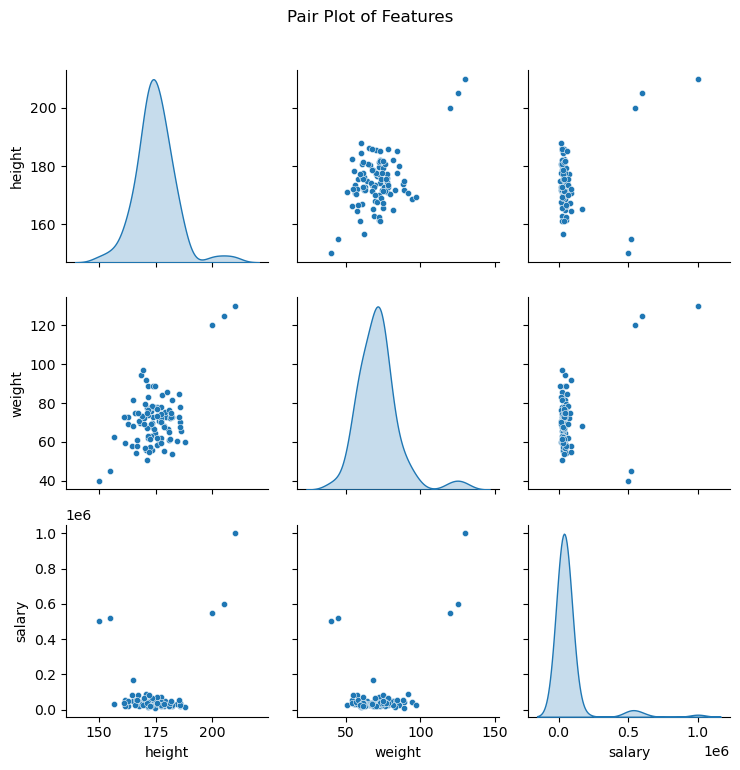

In [28]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Sujal\AppData\Local\Temp\ipykernel_5556\3117540217.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


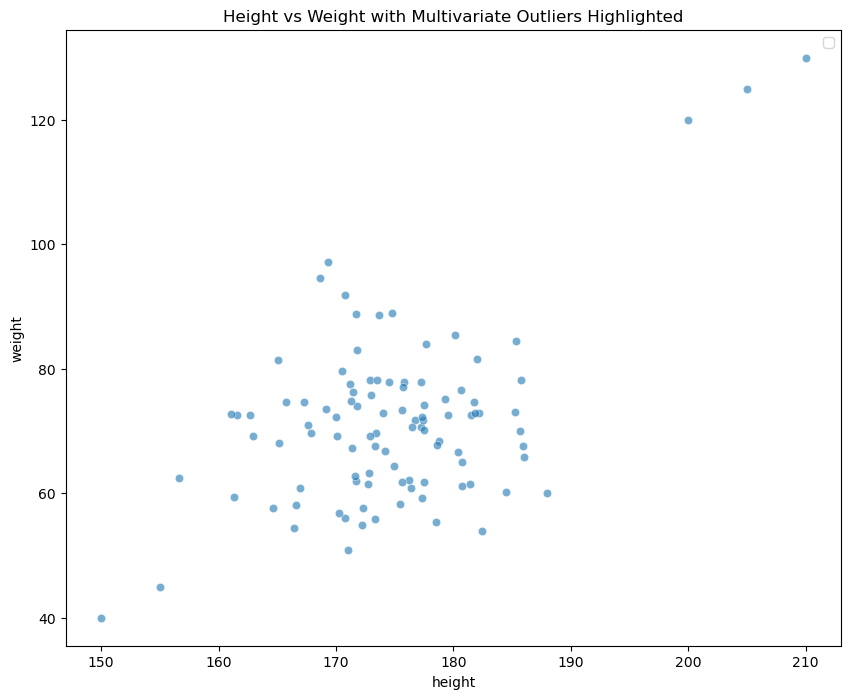

In [29]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


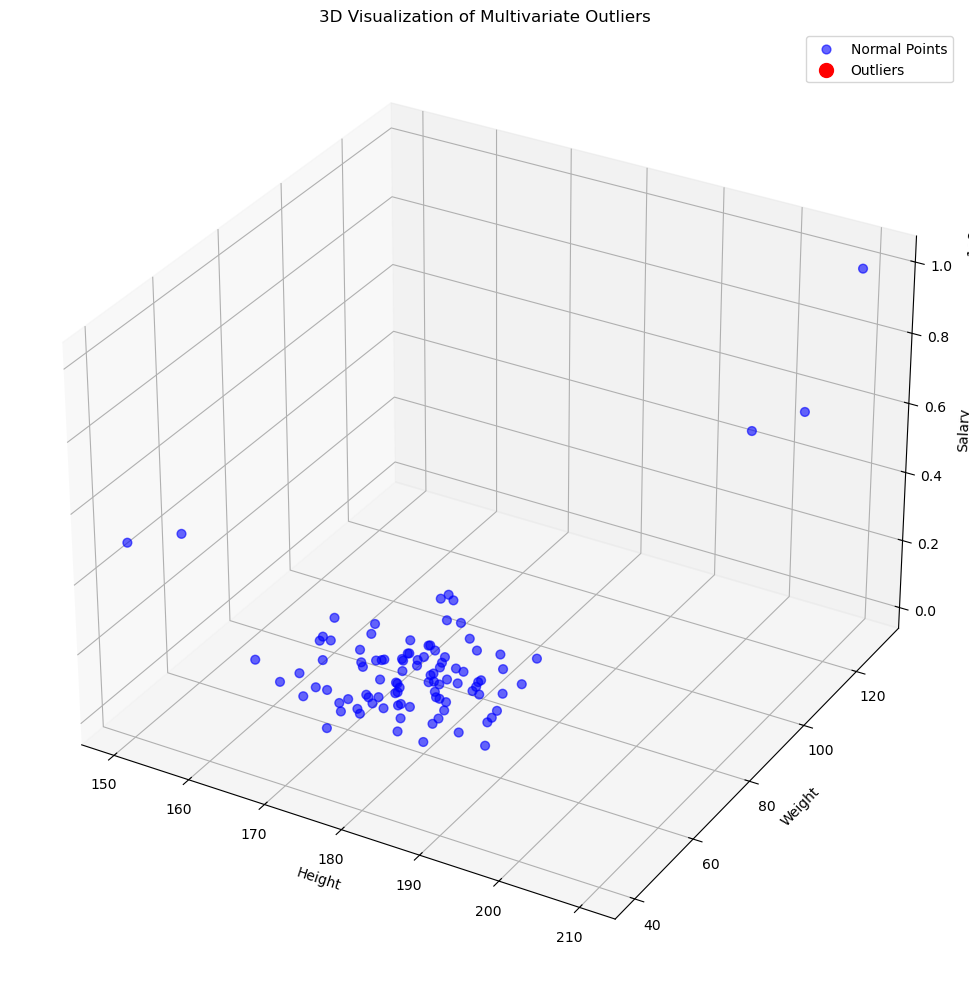

In [30]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()


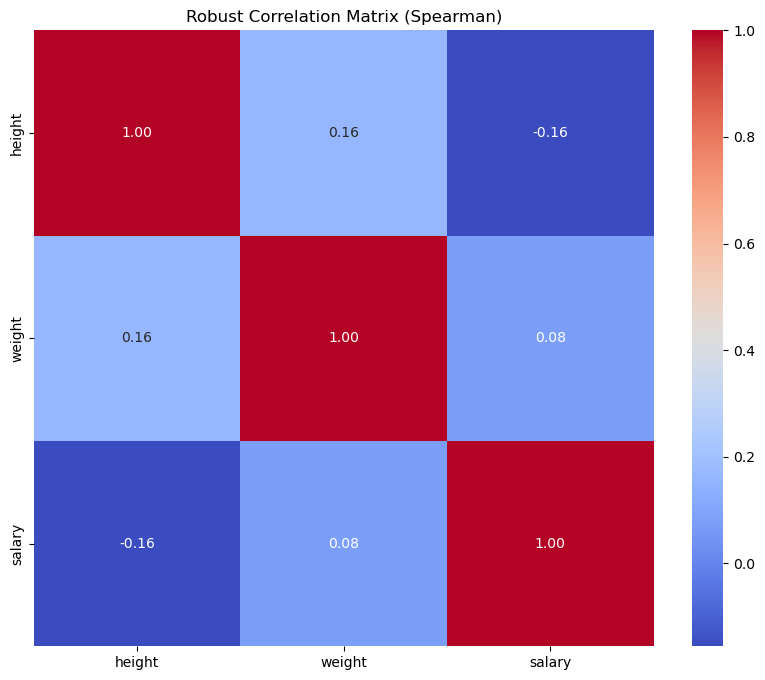

In [31]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()


In [32]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [33]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)


In [34]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

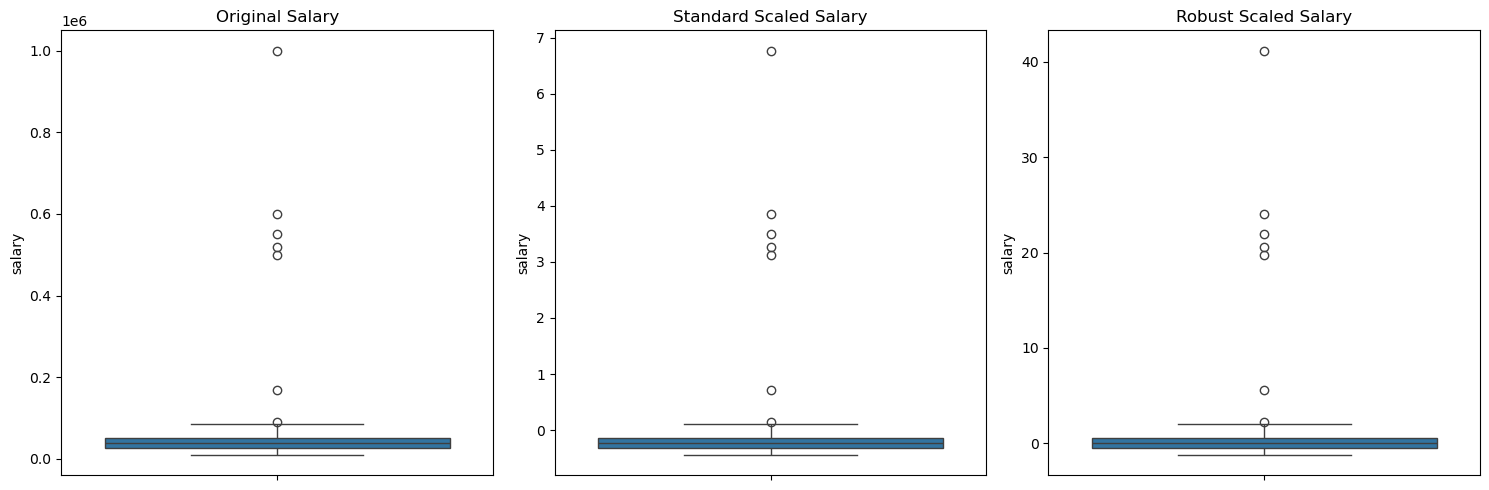

In [35]:
# Compare the scaled distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')

plt.tight_layout()
plt.show()


In [36]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [37]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'With Outlier: y = 2.57x + 1.40')

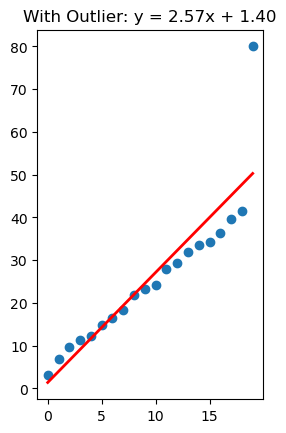

In [38]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')


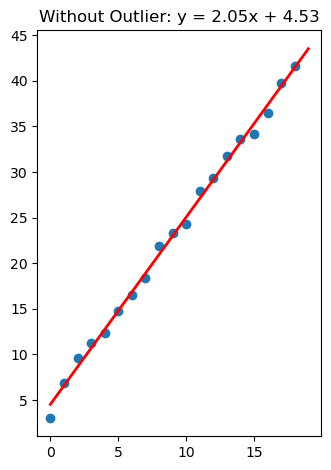

In [39]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

# Interactive Coding Exercise: Advanced Outlier Detection & Analysis


In [40]:
# ----------------------------------------------------------------
# In this exercise, you'll work with a real-world dataset to:
# 1. Apply outlier detection techniques
# 2. Compare methods and their impact
# 3. Implement a custom outlier detection workflow

In [41]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the California housing dataset instead of Boston
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Create a DataFrame with all features plus the target
df = X.copy()
df['MedHouseVal'] = y  # The target is median house value

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


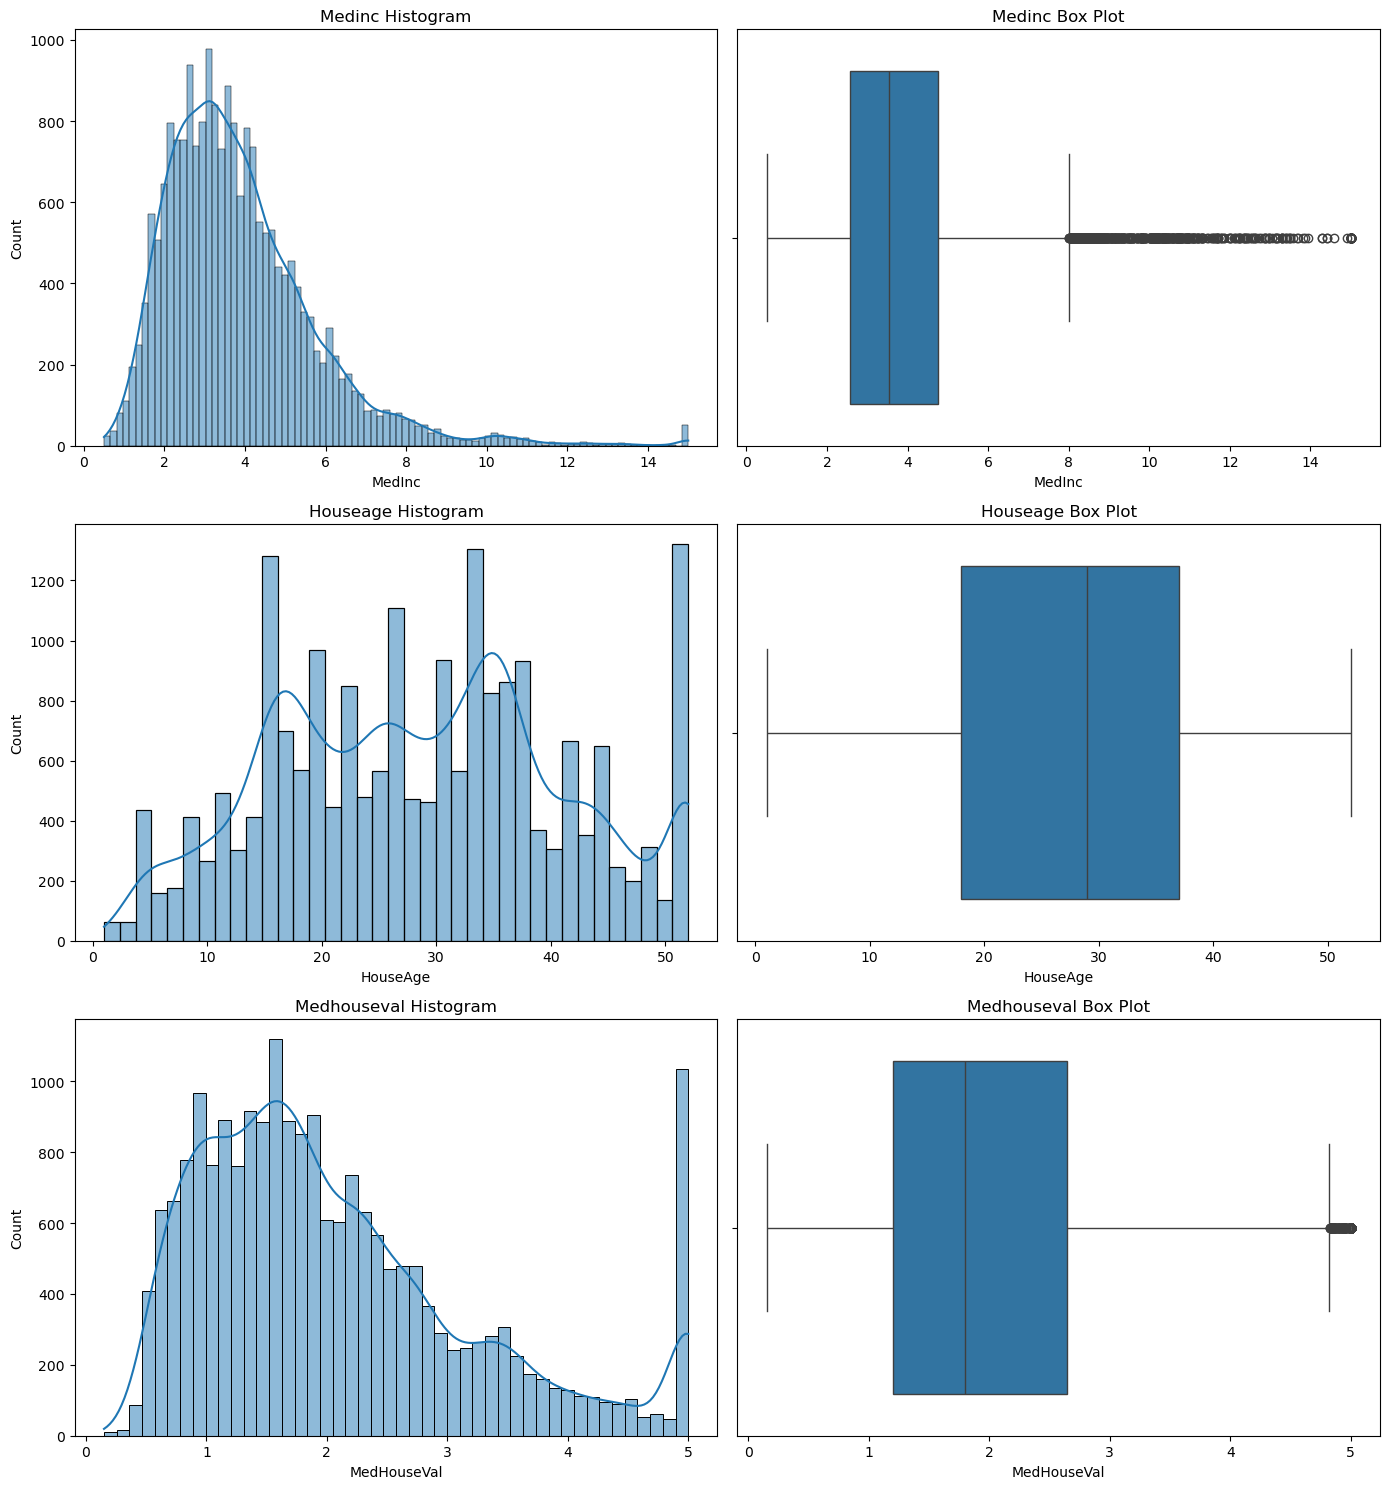

In [42]:
# EXERCISE 1: Exploratory Data Analysis for Outlier Detection
# -----------------------------------------------------------
# TODO: Create histograms and boxplots for at least 3 features to visually identify outliers
# Hint: Use subplot to organize multiple plots

plt.figure(figsize=(14, 15))
features = ['MedInc', 'HouseAge', 'MedHouseVal']

for i, col in enumerate(features):
    # Left column: Histogram plot karne ke liye
    plt.subplot(3, 2, 2 * i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col.capitalize()} Histogram')
    
    # Right column: Box plot plot karne ke liye
    plt.subplot(3, 2, 2 * i + 2)
    sns.boxplot(x=df[col])
    plt.title(f'{col.capitalize()} Box Plot')

# Overlapping se bachne ke liye layout auto-adjust karna
plt.tight_layout()
plt.show()

In [43]:
# EXERCISE 2: Implement Multiple Outlier Detection Methods
# -------------------------------------------------------
# TODO: Implement both Z-score and IQR outlier detection for the MedHouseVal feature
# MedHouseVal: % lower status of the population

# --- 1. Z-SCORE METHOD ---
medhouseval_z_scores = np.abs(stats.zscore(df['MedHouseVal']))
z_outliers = df[medhouseval_z_scores > 3]

print(f"--- Z-score Method ---")
print(f"Z-score Outliers Found: {len(z_outliers)}")


# --- 2. IQR METHOD ---
q1_val = df['MedHouseVal'].quantile(0.25)
q3_val = df['MedHouseVal'].quantile(0.75)
iqr_val = q3_val - q1_val

lower_bound_val = q1_val - 1.5 * iqr_val
upper_bound_val = q3_val + 1.5 * iqr_val

iqr_outliers = df[(df['MedHouseVal'] < lower_bound_val) | (df['MedHouseVal'] > upper_bound_val)]

print(f"\n--- IQR Method ---")
print(f"IQR Lower Bound: {lower_bound_val:.2f}, Upper Bound: {upper_bound_val:.2f}")
print(f"IQR Outliers Found: {len(iqr_outliers)}")


print("\nSample IQR Outliers (First 5 rows):")
print(iqr_outliers.head())

--- Z-score Method ---
Z-score Outliers Found: 0

--- IQR Method ---
IQR Lower Bound: -0.98, Upper Bound: 4.82
IQR Outliers Found: 1071

Sample IQR Outliers (First 5 rows):
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
89   1.2434      52.0  2.929412   0.917647       396.0  4.658824     37.80   
140  6.3624      30.0  5.615385   0.730769       126.0  2.423077     37.81   
459  1.1696      52.0  2.436000   0.944000      1349.0  5.396000     37.87   
489  3.0417      48.0  4.690632   1.126362      1656.0  3.607843     37.86   
493  7.8521      52.0  7.794393   1.051402       517.0  2.415888     37.86   

     Longitude  MedHouseVal  
89     -122.27      5.00001  
140    -122.18      4.83300  
459    -122.25      5.00001  
489    -122.25      4.89600  
493    -122.24      5.00001  


In [ ]:
# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------
# TODO: Implement the Isolation Forest algorithm to detect outliers in the dataset
# Use contamination=0.05 (assuming 5% of data points are outliers)
# Return a binary mask where -1 represents outliers

iso_forest = IsolationForest(contamination=0.05, random_state=42)

outlier_mask = iso_forest.fit_predict(df)

df['Is_Outlier'] = outlier_mask

print(f"Total rows in dataset: {df.shape[0]}")
print(f"Number of outliers detected (-1): {np.sum(outlier_mask == -1)}")
print(f"Number of normal points (1): {np.sum(outlier_mask == 1)}")

outliers_df = df[df['Is_Outlier'] == -1]
print("\nFirst 5 Outlier Rows:")
print(outliers_df.head())

Total rows in dataset: 20640
Number of outliers detected (-1): 1032
Number of normal points (1): 19608

First 5 Outlier Rows:
    MedInc  HouseAge  AveRooms  AveBedrms  Population   AveOccup  Latitude  \
59  2.5625       2.0  2.771930   0.754386        94.0   1.649123     37.82   
63  1.1910      52.0  7.698113   1.490566       521.0   3.276730     37.81   
73  0.4999      46.0  1.714286   0.571429        18.0   2.571429     37.81   
89  1.2434      52.0  2.929412   0.917647       396.0   4.658824     37.80   
91  0.8668      52.0  2.443182   0.988636       904.0  10.272727     37.80   

    Longitude  MedHouseVal  Is_Outlier  
59    -122.29      0.60000          -1  
63    -122.30      0.76100          -1  
73    -122.29      0.67500          -1  
89    -122.27      5.00001          -1  
91    -122.28      1.37500          -1  


In [49]:
# EXERCISE 4: Compare the Impact of Outliers on Linear Regression
# --------------------------------------------------------------
# TODO:
# 1. Create a simple linear regression model using 'MedInc' to predict 'MedHouseVal'
# 2. Create 3 versions:
#    a. With all data
#    b. After removing Z-score outliers
#    c. After removing Isolation Forest outliers
# 3. Compare the model performance metrics (r2_score) and coefficients

X_col = 'MedInc'
y_col = 'MedHouseVal'

def evaluate_lr(data, description):
    X_temp = data[[X_col]]
    y_temp = data[y_col]
    
    X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    coef = model.coef_[0]
    
    print(f"=== {description} ===")
    print(f"Data Points: {len(data)}")
    print(f"Coefficient (Slope): {coef:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"R² Score: {r2:.4f}\n")
    
    return {'R2': r2, 'MSE': mse, 'Coef': coef}

results_all = evaluate_lr(df, "Version A: With All Data")

z_scores = np.abs(stats.zscore(df[y_col]))
df_clean_z = df[z_scores <= 3]
results_z = evaluate_lr(df_clean_z, "Version B: Without Z-Score Outliers")

if 'Is_Outlier' not in df.columns:
    iso = IsolationForest(contamination=0.05, random_state=42)
    df['Is_Outlier'] = iso.fit_predict(df)

df_clean_iso = df[df['Is_Outlier'] == 1]
results_iso = evaluate_lr(df_clean_iso, "Version C: Without Isolation Forest Outliers")


=== Version A: With All Data ===
Data Points: 20640
Coefficient (Slope): 0.4193
Mean Squared Error (MSE): 0.7091
R² Score: 0.4589

=== Version B: Without Z-Score Outliers ===
Data Points: 20640
Coefficient (Slope): 0.4193
Mean Squared Error (MSE): 0.7091
R² Score: 0.4589

=== Version C: Without Isolation Forest Outliers ===
Data Points: 19608
Coefficient (Slope): 0.4533
Mean Squared Error (MSE): 0.6639
R² Score: 0.4420



=== Outlier Detection Summary for 'MedHouseVal' ===
IQR Outliers Detected: 1071
Z-Score Outliers Detected: 1011
Consensus Outliers (Detected by Both): 1011



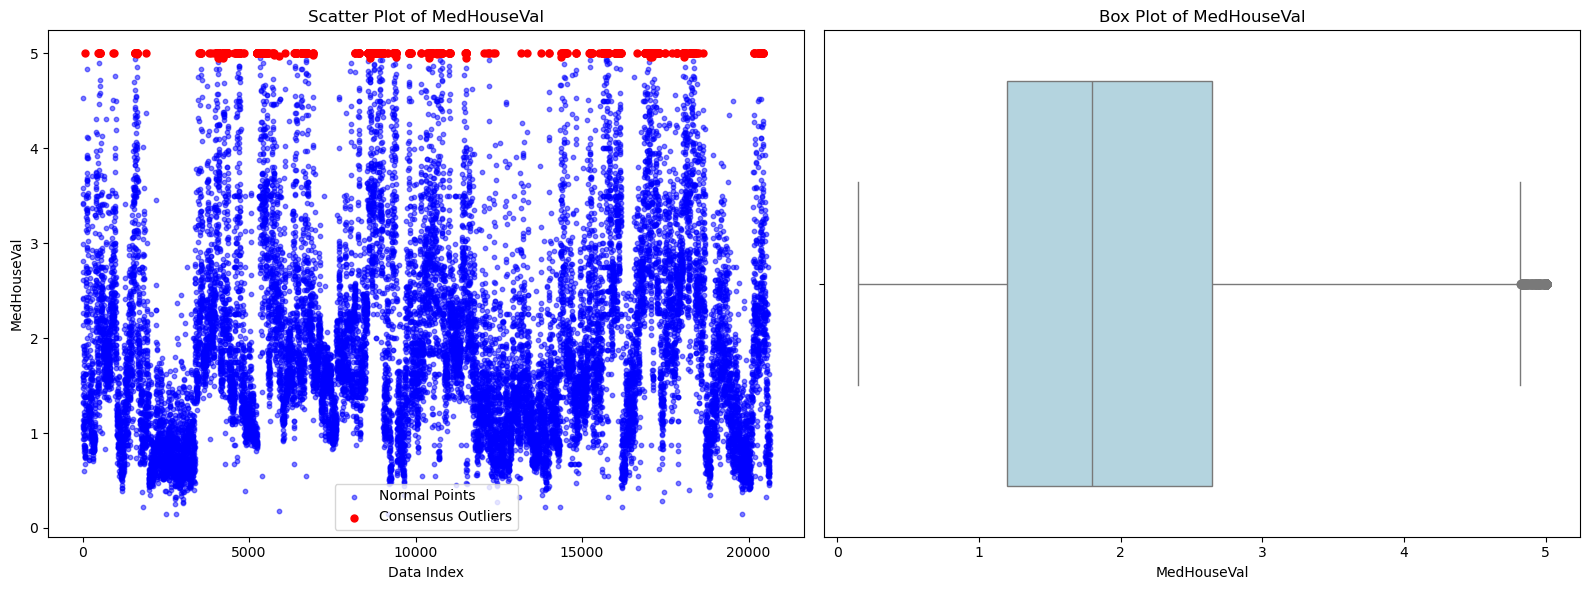

In [50]:
# EXERCISE 5: Create Your Own Outlier Detection Workflow
# -----------------------------------------------------
# TODO: Create a custom outlier detection function that combines multiple methods
# It should:
# 1. Take a dataframe and column name as input
# 2. Apply at least 2 different outlier detection methods (of your choice)
# 3. Return the indices of consensus outliers (detected by both methods)
# 4. Include a visualization of the outliers

def custom_outlier_detector(data, column_name):
    q1 = data[column_name].quantile(0.25)
    q3 = data[column_name].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    iqr_outliers_indices = data[(data[column_name] < lower_bound) | (data[column_name] > upper_bound)].index
    
    z_scores = np.abs(stats.zscore(data[column_name]))
    z_outliers_indices = data[z_scores > 2.5].index
    
    consensus_indices = iqr_outliers_indices.intersection(z_outliers_indices)
    
    print(f"=== Outlier Detection Summary for '{column_name}' ===")
    print(f"IQR Outliers Detected: {len(iqr_outliers_indices)}")
    print(f"Z-Score Outliers Detected: {len(z_outliers_indices)}")
    print(f"Consensus Outliers (Detected by Both): {len(consensus_indices)}\n")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].scatter(data.index, data[column_name], color='blue', alpha=0.5, label='Normal Points', s=10)
    axes[0].scatter(consensus_indices, data.loc[consensus_indices, column_name], color='red', label='Consensus Outliers', s=25)
    axes[0].set_title(f"Scatter Plot of {column_name}")
    axes[0].set_xlabel("Data Index")
    axes[0].set_ylabel(column_name)
    axes[0].legend()
    
    sns.boxplot(ax=axes[1], x=data[column_name], color='lightblue')
    axes[1].set_title(f"Box Plot of {column_name}")
    
    plt.tight_layout()
    plt.show()
    
    return consensus_indices

consensus_outliers = custom_outlier_detector(df, 'MedHouseVal')

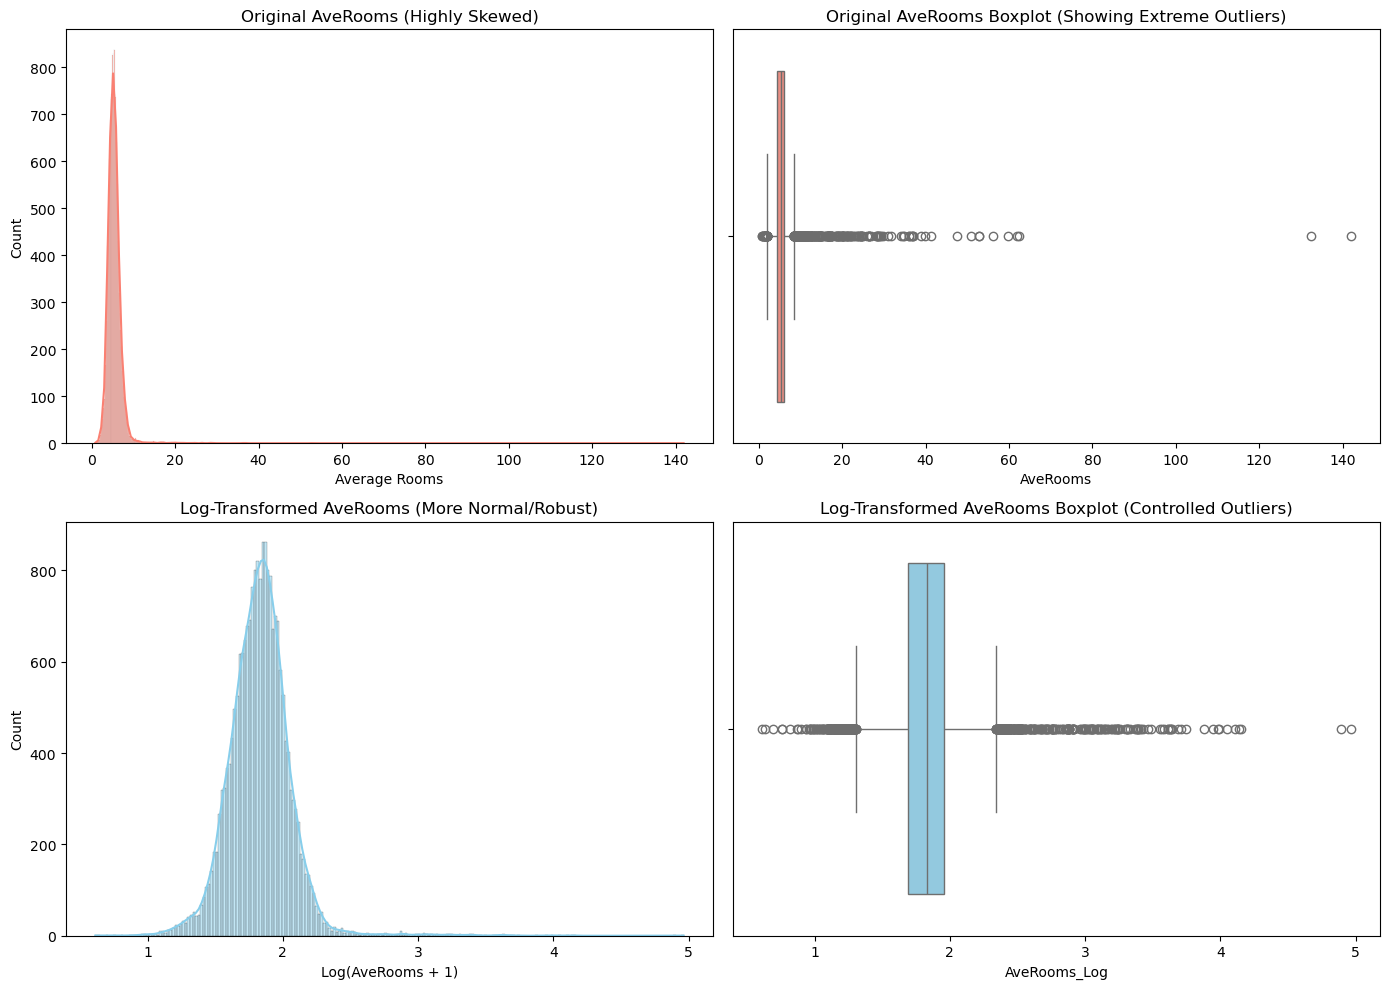

=== Descriptive Statistics Comparison ===

Original 'AveRooms':
count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: AveRooms, dtype: float64
Skewness: 20.70

Log-Transformed 'AveRooms_Log':
count    20640.000000
mean         1.828722
std          0.231938
min          0.613104
25%          1.693911
50%          1.829236
75%          1.953365
max          4.962209
Name: AveRooms_Log, dtype: float64
Skewness: 1.39


In [51]:
# EXERCISE 6: Robust Feature Engineering with Outliers
# ---------------------------------------------------
# TODO: Create a new feature that is more robust to outliers
# Suggestions:
# - Use log transformation
# - Use binning/discretization
# - Create a ratio or interaction feature
# Compare the distribution before and after your transformation

original_feature = df['AveRooms']

df['AveRooms_Log'] = np.log1p(df['AveRooms'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(original_feature, kde=True, ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Original AveRooms (Highly Skewed)')
axes[0, 0].set_xlabel('Average Rooms')

sns.boxplot(x=original_feature, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Original AveRooms Boxplot (Showing Extreme Outliers)')

sns.histplot(df['AveRooms_Log'], kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Log-Transformed AveRooms (More Normal/Robust)')
axes[1, 0].set_xlabel('Log(AveRooms + 1)')

sns.boxplot(x=df['AveRooms_Log'], ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title('Log-Transformed AveRooms Boxplot (Controlled Outliers)')

plt.tight_layout()
plt.show()

print("=== Descriptive Statistics Comparison ===")
print("\nOriginal 'AveRooms':")
print(original_feature.describe())
print(f"Skewness: {original_feature.skew():.2f}")

print("\nLog-Transformed 'AveRooms_Log':")
print(df['AveRooms_Log'].describe())
print(f"Skewness: {df['AveRooms_Log'].skew():.2f}")

=== Mahalanobis Multivariate Outlier Detection ===
Degrees of Freedom (Features count): 4
Chi-Squared Threshold (at alpha=0.01): 13.2767
Total Outliers Detected: 555 (out of 20640 points)



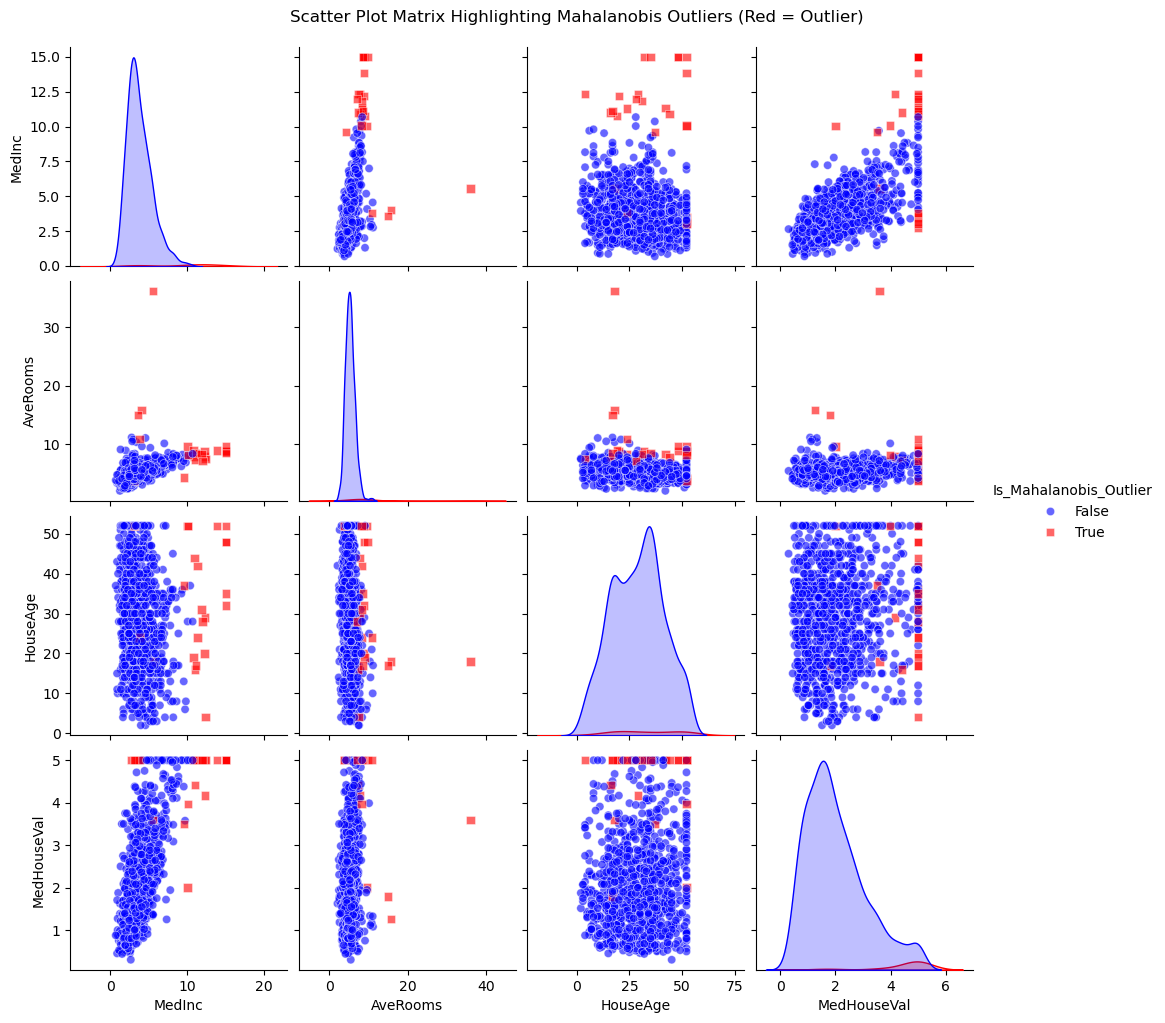

In [53]:
# EXERCISE 7: BONUS CHALLENGE - Multivariate Outlier Detection
# ------------------------------------------------------------
# TODO: Implement a multivariate outlier detection method using Mahalanobis distance
# Calculate the distance for each point and identify outliers using a chi-squared threshold
# Visualize the results using a scatter plot matrix highlighting the outliers

from scipy.stats import chi2

features_for_mahalanobis = ['MedInc', 'AveRooms', 'HouseAge', 'MedHouseVal']
data_subset = df[features_for_mahalanobis]

mean_vector = data_subset.mean()
covariance_matrix = data_subset.cov()

inv_covariance_matrix = np.linalg.inv(covariance_matrix)

diff = data_subset - mean_vector

mahalanobis_distances = np.sum(np.dot(diff, inv_covariance_matrix) * diff, axis=1)
df['Mahalanobis_Dist'] = mahalanobis_distances

degrees_of_freedom = len(features_for_mahalanobis)
# Significance level alpha = 0.01 (99% confidence level)
alpha = 0.01
chi2_threshold = chi2.ppf(1 - alpha, df=degrees_of_freedom)

df['Is_Mahalanobis_Outlier'] = df['Mahalanobis_Dist'] > chi2_threshold
mahalanobis_outliers_count = df['Is_Mahalanobis_Outlier'].sum()

print(f"=== Mahalanobis Multivariate Outlier Detection ===")
print(f"Degrees of Freedom (Features count): {degrees_of_freedom}")
print(f"Chi-Squared Threshold (at alpha={alpha}): {chi2_threshold:.4f}")
print(f"Total Outliers Detected: {mahalanobis_outliers_count} (out of {len(df)} points)\n")

sample_df = df.sample(n=1000, random_state=42).copy()

g = sns.pairplot(
    sample_df, 
    vars=features_for_mahalanobis, 
    hue='Is_Mahalanobis_Outlier', 
    palette={True: 'red', False: 'blue'}, 
    markers=['o', 's'],  # 'o' (circle) aur 's' (square) dono filled hain
    plot_kws={'alpha': 0.6}
)
g.fig.suptitle("Scatter Plot Matrix Highlighting Mahalanobis Outliers (Red = Outlier)", y=1.02)
plt.show()